In [1]:
import pandas as pd

df = pd.read_csv("final_dataset.csv")

df.head()

,Crop,Week,Price
0,Apple,apr_week1,11216.40
1,Apple,apr_week2,11595.56
2,Apple,feb_week1,9187.42
3,Apple,feb_week2,9607.11
4,Apple,feb_week3,10004.91


In [2]:
def convert_week(w):
    month_map = {"feb":1, "mar":2, "apr":3}
    parts = w.split("_")
    month = month_map[parts[0]]
    week = int(parts[1].replace("week", ""))
    return month * 4 + week

df["Time"] = df["Week"].apply(convert_week)

df.head()

,Crop,Week,Price,Time
0,Apple,apr_week1,11216.40,13
1,Apple,apr_week2,11595.56,14
2,Apple,feb_week1,9187.42,5
3,Apple,feb_week2,9607.11,6
4,Apple,feb_week3,10004.91,7


In [30]:
crop = "Maize"

crop_df = df[df["Crop"] == crop].sort_values("Time")

crop_df

,Crop,Week,Price,Time
112,Maize,feb_week1,1900.29,5
113,Maize,feb_week2,1850.31,6
114,Maize,feb_week3,1865.28,7
115,Maize,feb_week4,1883.83,8
116,Maize,mar_week1,1801.96,9
117,Maize,mar_week2,1838.20,10
118,Maize,mar_week3,1833.44,11
119,Maize,mar_week4,1855.61,12
110,Maize,apr_week1,1829.52,13
111,Maize,apr_week2,1815.02,14


In [31]:
# Train = first 9 weeks
train = crop_df.iloc[:-1]

# Test = last week (W10)
test = crop_df.iloc[-1:]

print("Train data:")
print(train)

print("\nTest data:")
print(test)

Train data:
      Crop       Week    Price  Time
112  Maize  feb_week1  1900.29     5
113  Maize  feb_week2  1850.31     6
114  Maize  feb_week3  1865.28     7
115  Maize  feb_week4  1883.83     8
116  Maize  mar_week1  1801.96     9
117  Maize  mar_week2  1838.20    10
118  Maize  mar_week3  1833.44    11
119  Maize  mar_week4  1855.61    12
110  Maize  apr_week1  1829.52    13

Test data:
      Crop       Week    Price  Time
111  Maize  apr_week2  1815.02    14


In [32]:
from sklearn.linear_model import LinearRegression

X_train = train[["Time"]]
y_train = train["Price"]

model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [33]:
X_test = test[["Time"]]
y_test = test["Price"]

pred = model.predict(X_test)

print("Actual Price (W10):", y_test.values[0])
print("Predicted Price (W10):", pred[0])

Actual Price (W10): 1815.02
Predicted Price (W10): 1819.5636111111112


In [34]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, pred)


print("MAE (Error):", mae)

MAE (Error): 4.543611111111204


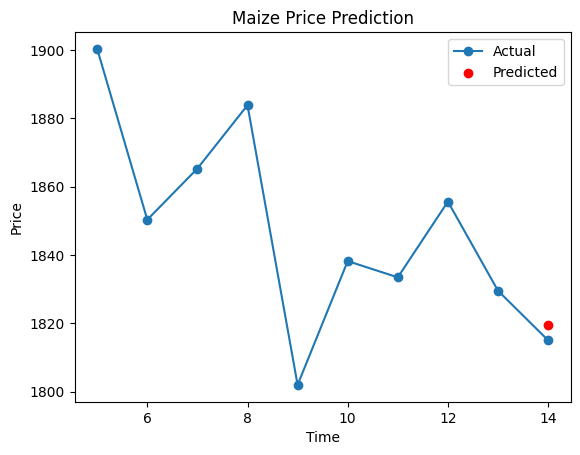

In [35]:
import matplotlib.pyplot as plt

plt.plot(crop_df["Time"], crop_df["Price"], marker='o', label="Actual")
plt.scatter(X_test, pred, color='red', label="Predicted")
plt.legend()
plt.title(f"{crop} Price Prediction")
plt.xlabel("Time")
plt.ylabel("Price")
plt.show()

In [36]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

models = {
    "Linear Regression": LinearRegression(),
    "Decision Tree": DecisionTreeRegressor(),
    "Random Forest": RandomForestRegressor()
}

for name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    
    error = abs(y_test.values[0] - pred[0])
    
    print(f"{name}:")
    print(f"Predicted: {pred[0]}")
    print(f"Error: {error}")
    print("------")

Linear Regression:
Predicted: 1819.5636111111112
Error: 4.543611111111204
------
Decision Tree:
Predicted: 1829.52
Error: 14.5
------
Random Forest:
Predicted: 1837.099099999998
Error: 22.079099999998107
------


In [20]:
from sklearn.ensemble import RandomForestRegressor

best_model = RandomForestRegressor()

# Train on ALL data (not just 9 weeks now)
X_full = crop_df[["Time"]]
y_full = crop_df["Price"]

best_model.fit(X_full, y_full)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [21]:
next_time = [[crop_df["Time"].max() + 1]]

future_pred = best_model.predict(next_time)

print("📈 Next Week Price Prediction:", future_pred[0])

📈 Next Week Price Prediction: 11458.373600000019


C:\Users\Medha Trust\AppData\Roaming\Python\Python312\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


In [37]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

print("📊 MODEL COMPARISON FOR ALL CROPS\n")

for crop in df["Crop"].unique():
    
    crop_df = df[df["Crop"] == crop].sort_values("Time")
    
    # Skip if not enough data
    if len(crop_df) < 2:
        continue
    
    # Train/Test split
    train = crop_df.iloc[:-1]
    test = crop_df.iloc[-1:]
    
    X_train = train[["Time"]]
    y_train = train["Price"]
    
    X_test = test[["Time"]]
    y_test = test["Price"]
    
    # Models
    models = {
        "Linear Regression": LinearRegression(),
        "Decision Tree": DecisionTreeRegressor(),
        "Random Forest": RandomForestRegressor()
    }
    
    print(f"\n🌾 Crop: {crop}")
    
    for name, model in models.items():
        model.fit(X_train, y_train)
        pred = model.predict(X_test)
        
        error = abs(y_test.values[0] - pred[0])
        
        print(f"{name}: Predicted={pred[0]:.2f}, Error={error:.2f}")
    
    print("-" * 50)

📊 MODEL COMPARISON FOR ALL CROPS


🌾 Crop: Apple
Linear Regression: Predicted=11936.66, Error=341.10
Decision Tree: Predicted=11216.40, Error=379.16
Random Forest: Predicted=11251.57, Error=343.99
--------------------------------------------------

🌾 Crop: Banana
Linear Regression: Predicted=3187.28, Error=277.88
Decision Tree: Predicted=2968.27, Error=58.87
Random Forest: Predicted=3015.07, Error=105.67
--------------------------------------------------

🌾 Crop: Beans
Linear Regression: Predicted=5079.37, Error=48.12
Decision Tree: Predicted=4922.30, Error=205.19
Random Forest: Predicted=4889.80, Error=237.69
--------------------------------------------------

🌾 Crop: Black Gram
Linear Regression: Predicted=9060.02, Error=1047.57
Decision Tree: Predicted=8536.57, Error=524.12
Random Forest: Predicted=8667.42, Error=654.97
--------------------------------------------------

🌾 Crop: Chickpea
Linear Regression: Predicted=6824.61, Error=25.79
Decision Tree: Predicted=6883.10, Error=84.28


In [40]:
from sklearn.ensemble import RandomForestRegressor

print("📈 FINAL NEXT WEEK PREDICTIONS\n")

for crop in df["Crop"].unique():
    
    crop_df = df[df["Crop"] == crop].sort_values("Time")
    
    X = crop_df[["Time"]]
    y = crop_df["Price"]
    
    model = RandomForestRegressor()
    model.fit(X, y)
    
    next_time = pd.DataFrame({
    "Time": [crop_df["Time"].max() + 1]})

    pred = model.predict(next_time)
    
    print(f"{crop}: {pred[0]:.2f}")

📈 FINAL NEXT WEEK PREDICTIONS

Apple: 11477.85
Banana: 2942.96
Beans: 5037.04
Black Gram: 8270.70
Chickpea: 6798.44
Coconut: 12795.32
Coffee: 20229.28
Cotton: 7598.76
Grapes: 8244.89
Jute: 10850.18
Lentil: 7758.02
Maize: 1821.56
Mango: 8714.34
Musk: 2197.24
Orange: 7966.30
Papaya: 2643.29
Peas(Dry): 4908.53
Pomegranate: 10229.61
Rice: 4394.11
Water Melon: 1491.52
